In [50]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warning = warnings.filterwarnings("ignore")

In [51]:
df = pd.read_csv("student_performance.csv")

In [52]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [53]:
df.shape

(10000, 6)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [55]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [56]:
df.duplicated().sum()

np.int64(127)

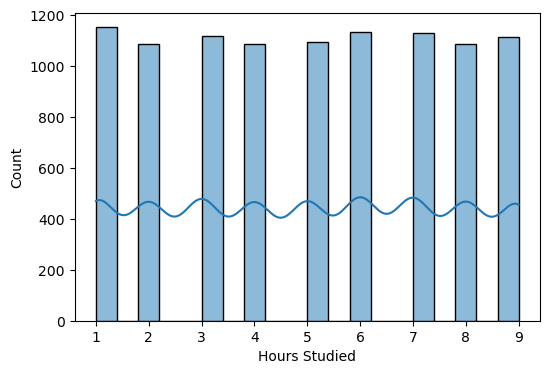

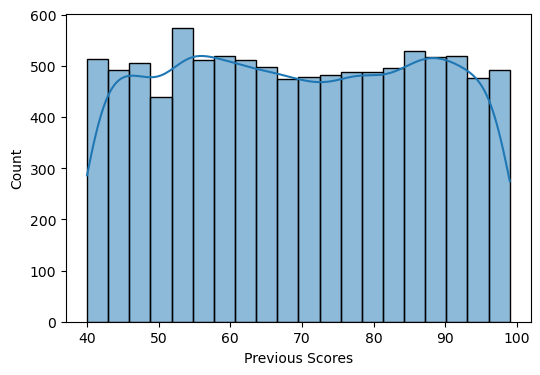

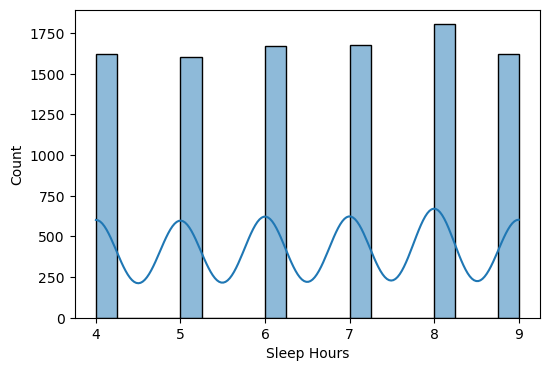

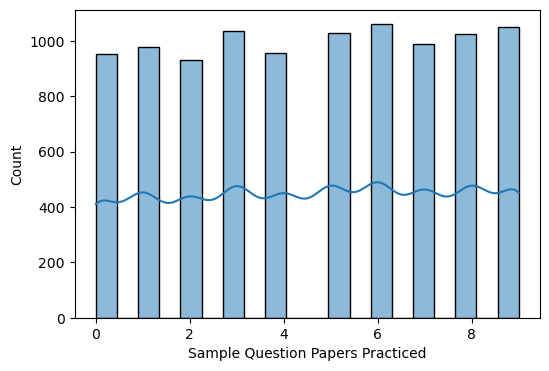

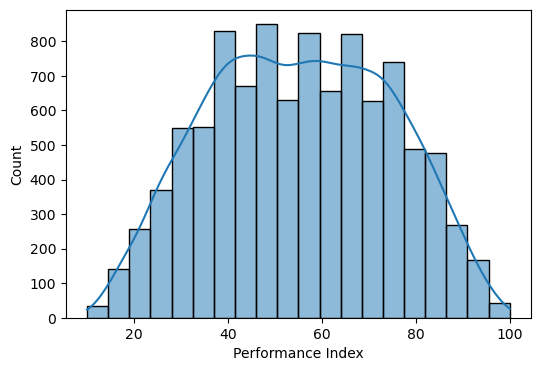

In [59]:
numeric_columns = ["Hours Studied", "Previous Scores", "Sleep Hours", "Sample Question Papers Practiced", "Performance Index"]
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], kde = True, bins = 20 )

<Axes: xlabel='Extracurricular Activities', ylabel='count'>

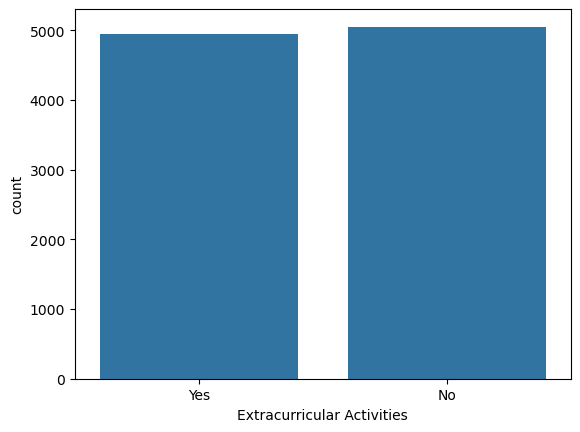

In [60]:
sns.countplot(x = df["Extracurricular Activities"])

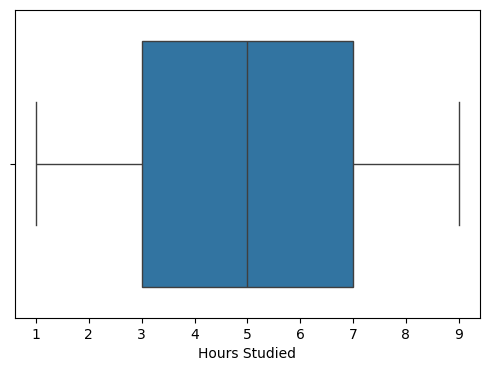

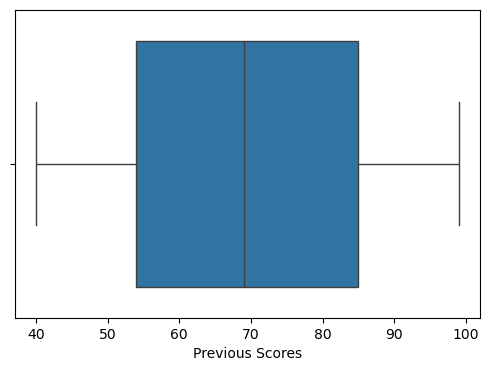

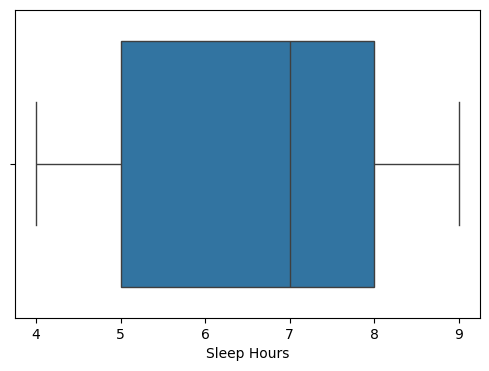

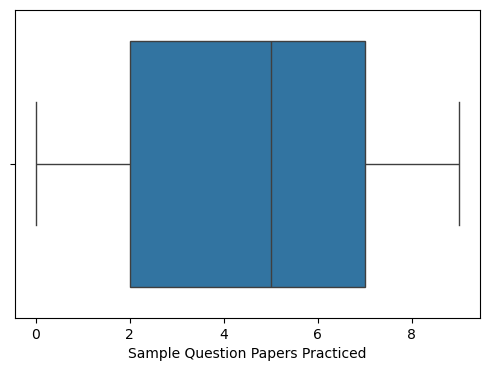

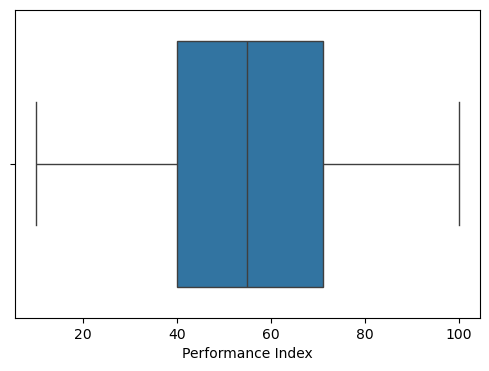

In [61]:
numeric_columns = ["Hours Studied", "Previous Scores", "Sleep Hours", "Sample Question Papers Practiced", "Performance Index"]
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.boxplot(x = df[col])

# Explorartory Data Analysis (EDA)

<Axes: xlabel='Performance Index', ylabel='Count'>

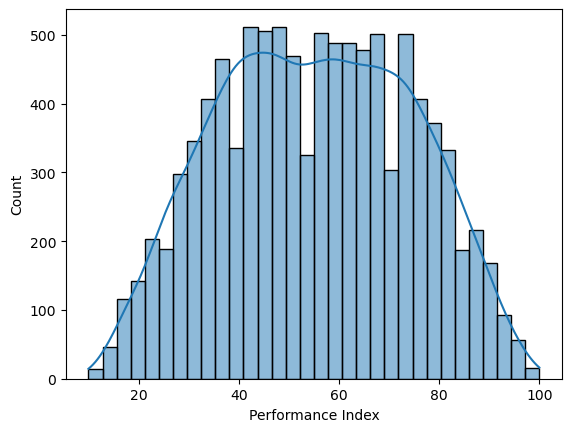

In [62]:
sns.histplot(df["Performance Index"], kde = True)

<Axes: >

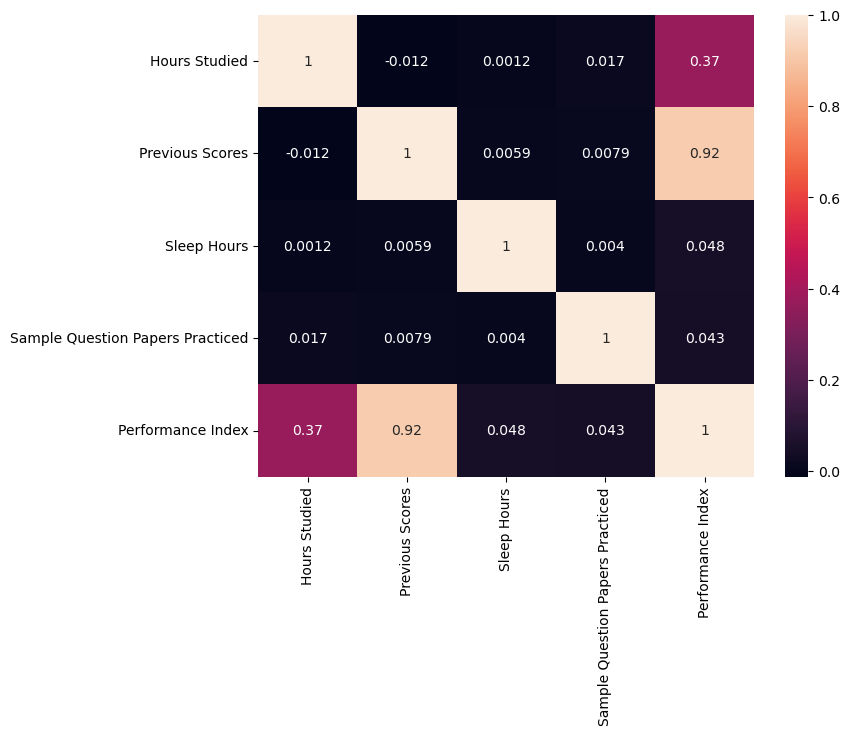

In [63]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only = True), annot = True)

# Data Cleaning and preprocessing

In [64]:
df_clean = df.copy()

In [65]:
df_clean.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [66]:
df_clean.shape

(10000, 6)

In [67]:
df_clean.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [68]:
df_clean.duplicated().sum()

np.int64(127)

In [69]:
df_clean.drop_duplicates(inplace = True)

In [70]:
df_clean.shape

(9873, 6)

In [71]:
df_clean.dtypes

Hours Studied                        int64
Previous Scores                      int64
Extracurricular Activities          object
Sleep Hours                          int64
Sample Question Papers Practiced     int64
Performance Index                    int64
dtype: object

In [72]:
df_clean["Extracurricular Activities"].value_counts()

Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64

In [73]:
df_clean["Extracurricular Activities"] = df_clean["Extracurricular Activities"].map({"No" : 0, "Yes" : 1})

In [74]:
df_clean

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66
...,...,...,...,...,...,...
9995,1,49,1,4,2,23
9996,7,64,1,8,5,58
9997,6,83,1,8,5,74
9998,9,97,1,7,0,95


In [75]:
df_clean = df_clean.reset_index(drop = True)

In [76]:
df_clean

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66
...,...,...,...,...,...,...
9868,1,49,1,4,2,23
9869,7,64,1,8,5,58
9870,6,83,1,8,5,74
9871,9,97,1,7,0,95


# Multiple Linear Regression
- input will be more than 1
- equation: y = (M1X1) + (M2X2)+ ... +(MnXn) + Bias

In [77]:
df_clean.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66


# Model Training

In [79]:
X = df_clean.drop(["Performance Index"], axis = 1)
X = df_clean[["Hours Studied", "Previous Scores", "Extracurricular Activities", "Sleep Hours", "Sample Question Papers Practiced"]]
y = df_clean["Performance Index"]

In [80]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [81]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [82]:
model.coef_

array([2.8510219 , 1.01843034, 0.57382297, 0.47207329, 0.18870366])

In [83]:
model.intercept_

np.float64(-33.98132449644065)

# Predictions on Training Data

In [84]:
y_pred_train = model.predict(X_train)

In [85]:
from sklearn.metrics import mean_squared_error, r2_score

In [86]:
from math import sqrt
sqrt(mean_squared_error(y_train, y_pred_train))

2.0358228155328564

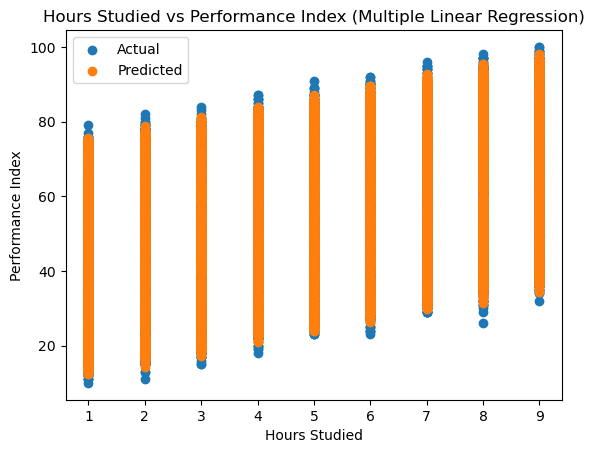

In [88]:
plt.scatter(X_train["Hours Studied"], y_train, label="Actual")
plt.scatter(X_train["Hours Studied"], y_pred_train, label="Predicted")

plt.title("Hours Studied vs Performance Index (Multiple Linear Regression)")
plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.legend()

plt.show()

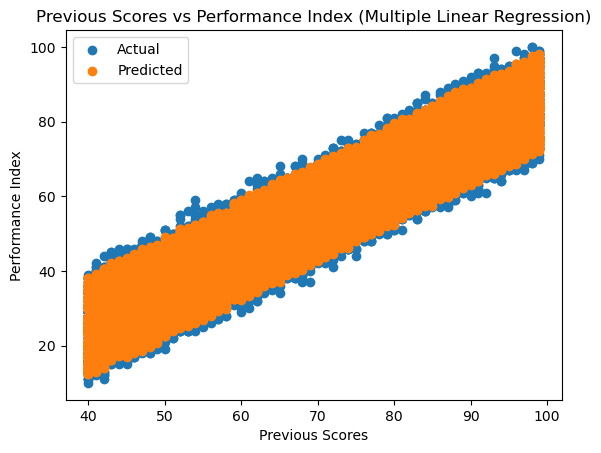

In [89]:
plt.scatter(X_train["Previous Scores"], y_train, label="Actual")
plt.scatter(X_train["Previous Scores"], y_pred_train, label="Predicted")

plt.title("Previous Scores vs Performance Index (Multiple Linear Regression)")
plt.xlabel("Previous Scores")
plt.ylabel("Performance Index")
plt.legend()

plt.show()

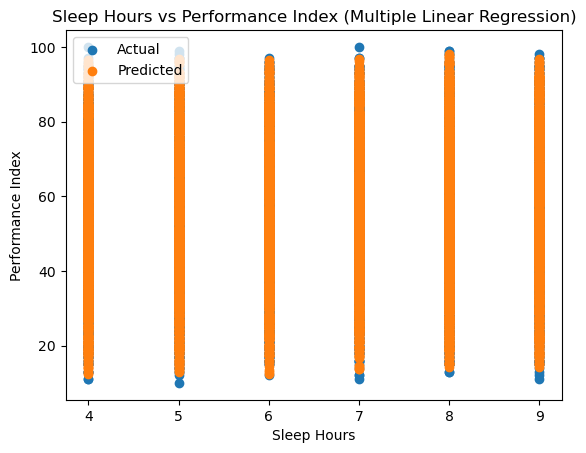

In [90]:
plt.scatter(X_train["Sleep Hours"], y_train, label="Actual")
plt.scatter(X_train["Sleep Hours"], y_pred_train, label="Predicted")

plt.title("Sleep Hours vs Performance Index (Multiple Linear Regression)")
plt.xlabel("Sleep Hours")
plt.ylabel("Performance Index")
plt.legend()

plt.show()

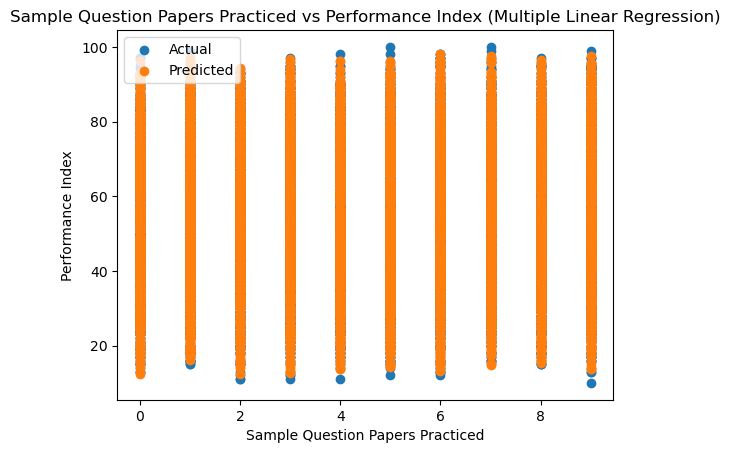

In [91]:
plt.scatter(X_train["Sample Question Papers Practiced"], y_train, label="Actual")
plt.scatter(X_train["Sample Question Papers Practiced"], y_pred_train, label="Predicted")

plt.title("Sample Question Papers Practiced vs Performance Index (Multiple Linear Regression)")
plt.xlabel("Sample Question Papers Practiced")
plt.ylabel("Performance Index")
plt.legend()

plt.show()

In [92]:
r2_score(y_train, y_pred_train)

0.9887391160677558

# Prediction on Testing Data

In [94]:
def performance_index_predictor(Hours_Studied, Previous_Scores, Extracurricular_Activities, Sleep_Hours, Sample_Question_Papers_Practiced):
    performance_index = model.predict([["Hours_Studied", "Previous_Scores", "Extracurricular_Activities", "Sleep_Hours", "Sample_Question_Papers_Practiced"]])
    return performance_index

In [95]:

def performance_index_predictor(Hours_Studied, Previous_Scores, Extracurricular_Activities, Sleep_Hours, Sample_Question_Papers_Practiced):
    input_data = pd.DataFrame([{
        'Hours Studied': int(Hours_Studied),
        'Previous Scores': int(Previous_Scores),
        'Extracurricular Activities': int(Extracurricular_Activities),
        'Sleep Hours': int(Sleep_Hours),
        'Sample Question Papers Practiced': int(Sample_Question_Papers_Practiced)
    }])

    return model.predict(input_data)

In [99]:
Hours_Studied = int(input("enter study hours: "))
Previous_Scores = int(input("enter previous score: "))

Extracurricular_Activities = input("enter extra curricular activities (yes/no): ").lower()
Extracurricular_Activities = 1 if Extracurricular_Activities == "yes" else 0

Sleep_Hours = int(input("enter sleep hours: "))
Sample_Question_Papers_Practiced = int(input("Sample_Question_Papers_Practiced: "))

predicted_performance = performance_index_predictor(Hours_Studied, Previous_Scores, Extracurricular_Activities, Sleep_Hours, Sample_Question_Papers_Practiced)

print(f"predicted performance: {predicted_performance[0]:}")

enter study hours:  7
enter previous score:  99
enter extra curricular activities (yes/no):  yes
enter sleep hours:  9
Sample_Question_Papers_Practiced:  1


predicted performance: 91.8116190571415
